# Neighbour feature operations - 1: MCGS2D

In [58]:
from upxo.ggrowth.mcgs import mcgs
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries
import upxo.gbops.mcgb2dops as gbops2d
import upxo.gsdataops.grid_ops as gridOps
import upxo.connops.neighbour_ops as neighOps
from copy import deepcopy

input_dashboard = 'C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\gschar\\gschar3.xls'
pxt = mcgs(input_dashboard=input_dashboard)
pxt.simulate()
pxt.detect_grains(library='cc3d', process_individual_states=True)
# pxt.gs[3].lgi = np.asarray(pxt.gs[3].lgi, dtype=np.int32)
tslice = 3
pxt.gs[tslice].char_morph_2d(npixels=True)
pxt.gs[tslice].find_neigh(include_central_grain=False, print_msg=True, use_numba=False,
                     user_defined_bbox_ex_bounds=False, bbox_ex_bounds=None,
                     update_grain_object=True)
pxtal = pxt.gs[tslice]

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\gschar\gschar3.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 8.0, 1.0
     ymin, ymax, yinc: 0.0, 8.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 50
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
..............................
Single crystal achieved at iteration 9.
GS temporal slice 9 stored

!! MONTE-CARLO ALG.202 run ended !!

|--------------- MC SIM RUN COMPLETED on: ALG200---------------|
Using cc3d for grain identification
Characterising MC si

In [59]:
pxtal.neigh_gid

{1: [2, 3, 4, 5, 6, 7, 8],
 2: [1, 4, 7],
 3: [1, 7, 8],
 4: [1, 2, 6, 7],
 5: [1, 6],
 6: [1, 4, 5],
 7: [1, 2, 3, 4],
 8: [1, 3]}

### Get fid of feature (grain) with maximum area

In [60]:
fid = np.argmax(pxtal.prop.npixels.to_numpy())+1

### Import the neighbour_ops module

In [61]:
import upxo.connops.neighbour_ops as neighOps

In [62]:
update_grain_object = True
get_gbsegs = True

#### explanations
* `update_grain_object`. If `True`, the `neigh` attribute of MCGS2D grain object (instantiated from `grain2d` from the module `upxo.xtal.mcgrain2d_definitions`) will be updated with the neighbourhood information of that specific grain.
* `get_gbsegs`. If `True`, the `gbsegs` attribute of MCGS2D grain object will be updated with the sparse representation of the gbsegs lfi array. To retrieve it, use as demonstrated below.

Neighbours are: [2 3 4 5 6 7 8]
----------------------------------------
Grain object updated. Neighbours stored in pxtal.g[1]['grain'].neigh. Threy are:
Neighbours are: [2 3 4 5 6 7 8]
----------------------------------------
Grain boundary segments stored in pxtal.g[1]['grain'].gbsegs. Keys are:

Storage format: Sparse representation with keys - 'shape', 'dtype', 'NZI', 'NZV'
....shape : Shape of the grain boundary segment array
....dtype : Data type of the grain boundary segment array
....NZI   : Non-zero indices of the grain boundary segment array
....NZV   : Non-zero values of the grain boundary segment array

Shape is: 
(7, 8)

Data type is: 
<class 'numpy.int32'>

Non-Zero indices are: 
[ 2  3  4  5  6  9 15 16 23 24 31 33 39 42 47 51 54]

Non-Zero values are: 
[3 7 7 7 2 3 4 3 4 3 6 8 5 8 5 8 5]
LETS RETRIEVE THE FULL GRAIN BOUNDARY SEGMENT ARRAY FROM THE SPARSE REPRESENTATION


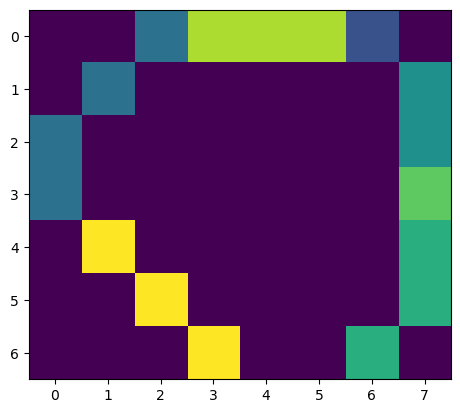

In [63]:
neighs = neighOps.find_neigh_fid(pxtal.g, pxtal.lfi, fid, pxtal.n, include_central_grain=False,
                update_grain_object=update_grain_object, user_defined_bbox_ex_bounds=False,
                bbox_ex_bounds_fid=None, use_numba=False, _char_fx_version_=pxtal._char_fx_version_,
                get_gbsegs=get_gbsegs, save_gbsegs=True, throw=True, throw_gbsegs=False)
print(f'Neighbours are: {neighs}'), print(40*'-')
if update_grain_object:
    print(f"Grain object updated. Neighbours stored in pxtal.g[{fid}][\'grain\'].neigh. Threy are:")
    print(f"Neighbours are: {pxtal.g[fid]['grain'].neigh}"), print(40*'-')
if get_gbsegs:
    print(f"Grain boundary segments stored in pxtal.g[{fid}][\'grain\'].gbsegs. Keys are:")
    print("\nStorage format: Sparse representation with keys - 'shape', 'dtype', 'NZI', 'NZV'")
    print('....shape : Shape of the grain boundary segment array')
    print('....dtype : Data type of the grain boundary segment array')
    print('....NZI   : Non-zero indices of the grain boundary segment array')
    print('....NZV   : Non-zero values of the grain boundary segment array')
    print(f"\nShape is: \n{pxtal.g[fid]['grain'].gbsegs['shape']}")
    print(f"\nData type is: \n{pxtal.g[fid]['grain'].gbsegs['dtype']}")
    print(f"\nNon-Zero indices are: \n{pxtal.g[fid]['grain'].gbsegs['NZI']}")
    print(f"\nNon-Zero values are: \n{pxtal.g[fid]['grain'].gbsegs['NZV']}")
    print('LETS RETRIEVE THE FULL GRAIN BOUNDARY SEGMENT ARRAY FROM THE SPARSE REPRESENTATION')
    gbseg_full = pxtal.g[fid]['grain'].lfi_gbsegs
    plt.imshow(gbseg_full)

In [64]:
pxtal.g[fid]['grain'].neigh

array([2, 3, 4, 5, 6, 7, 8], dtype=int32)

In [65]:
pxtal.g[fid]['grain'].gbsegs

{'shape': (7, 8),
 'NZI': array([ 2,  3,  4,  5,  6,  9, 15, 16, 23, 24, 31, 33, 39, 42, 47, 51, 54]),
 'NZV': array([3, 7, 7, 7, 2, 3, 4, 3, 4, 3, 6, 8, 5, 8, 5, 8, 5], dtype=int32),
 'dtype': numpy.int32}

In [66]:
pxtal.g[fid]['grain'].lfi_gbseg_empties = np.nan

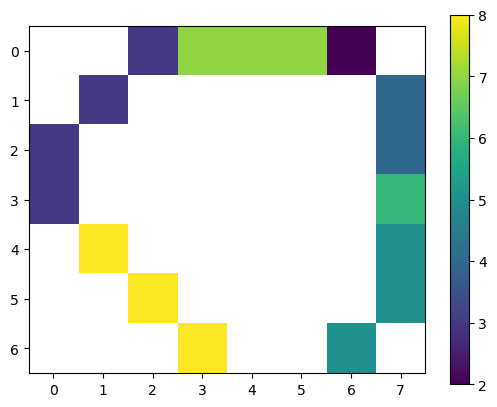

In [67]:
plt.imshow(pxtal.g[fid]['grain'].lfi_gbsegs)
plt.colorbar()

In [68]:
neigh_order = 1
neighbours = neighOps.get_upto_nth_order_neighbors(pxtal.lfi, pxtal.neigh_gid, 
                                                   fid, neigh_order,
                                                   fast_estimate=False,
                                                   recalculate=False, 
                                                   include_parent=True,
                                                   output_type='numpy')
# pxtal.plot_grains(neighbours)
neighbours

array([2, 3, 4, 5, 6, 7, 8])

## Workflow Overview
- **Neighbour feature operations for 2D Monte-Carlo Grain Structures (MCGS2D)**

## Key Operations you encountered in this workflow

1. **Grain Structure Simulation & Detection**
    - Creating an `mcgs` object from Excel dashboard
    - Running Monte-Carlo simulation (`simulate()`)
    - Detecting grains using `cc3d` library with state-based processing
    - Characterizing grain morphology (`char_morph_2d()`)
    - Finding neighbors for all grains (`find_neigh()`)

2. **Single Grain Analysis**
    - Identifying the grain with maximum area (using `npixels` property)
    - Finding neighbors for a specific grain using `neighOps.find_neigh_fid()`

3. **Grain Object Updates**
    - `update_grain_object=True`: Updates the `neigh` attribute of individual grain objects
    - `get_gbsegs=True`: Stores grain boundary segments in sparse representation

4. **Grain Boundary Segment Retrieval**
    - Understanding sparse representation format (shape, dtype, NZI, NZV)
    - Retrieving full grain boundary segment arrays from sparse storage
    - Visualizing grain boundary segments with `plt.imshow()`

5. **Higher-Order Neighbor Detection**
    - Using `get_upto_nth_order_neighbors()` to find nth-order neighbors
    - Parameters: `neigh_order`, `fast_estimate`, `recalculate`, `include_parent`, `output_type`

6. **Data Structures Explored**
    - `pxtal.g[fid]['grain'].neigh`: Neighbor list for a specific grain
    - `pxtal.g[fid]['grain'].gbsegs`: Sparse grain boundary segment data
    - `pxtal.g[fid]['grain'].lfi_gbsegs`: Full grain boundary segment array: Lazy computation

## Summary

### Modules Used
- `upxo.ggrowth.mcgs` - Monte-Carlo grain structure simulation
- `upxo.connops.neighbour_ops` - Neighbor detection and connectivity operations

### Primary Objective
Demonstrate **neighbor detection and grain boundary characterization** for individual grains in 2D Monte-Carlo grain structures, focusing on single-grain analysis workflows.

### Secondary Objective
Illustrate **grain boundary segment storage and retrieval** using sparse representation formats, enabling efficient memory usage for large-scale microstructure data.

### Tertiary Objective
Show **nth-order neighbor detection** capabilities, allowing hierarchical analysis of grain connectivity networks beyond immediate neighbors.

### Major Function Calls Demonstrated
1. **`mcgs.simulate()`** - Run Monte-Carlo grain growth simulation
2. **`mcgs.detect_grains(library='cc3d', process_individual_states=True)`** - Detect grains using connected components algorithm
3. **`mcgs2_grain_structure.char_morph_2d(npixels=True)`** - Characterize grain morphology (area in pixels)
4. **`mcgs2_grain_structure.find_neigh()`** - Find neighbors for all grains in the structure
5. **`neighOps.find_neigh_fid()`** - Find neighbors for a specific grain ID with optional grain object updates and grain boundary segment retrieval
6. **`neighOps.get_upto_nth_order_neighbors()`** - Retrieve nth-order neighbors with configurable parameters

### Images Generated
1. **Grain boundary segment visualization** for grain with maximum area (fid=1):
    - First image: Basic grain boundary segment array showing neighbor IDs at boundary pixels
    - Second image: Same visualization with colorbar for value interpretation
    
    Both images display the spatial distribution of grain boundary segments, where non-zero values indicate the neighbor grain ID at each boundary pixel location.

In [69]:
# pxtal.g[20]['grain'].bbox_ex

In [70]:
pxtal.n

8

In [71]:
lfi = deepcopy(pxtal.lfi)

In [72]:
fid = 1

In [73]:
fids = [1, 2, 3 , 4]

In [74]:
fids=None

In [75]:
from upxo.viz.gsviz import see_map

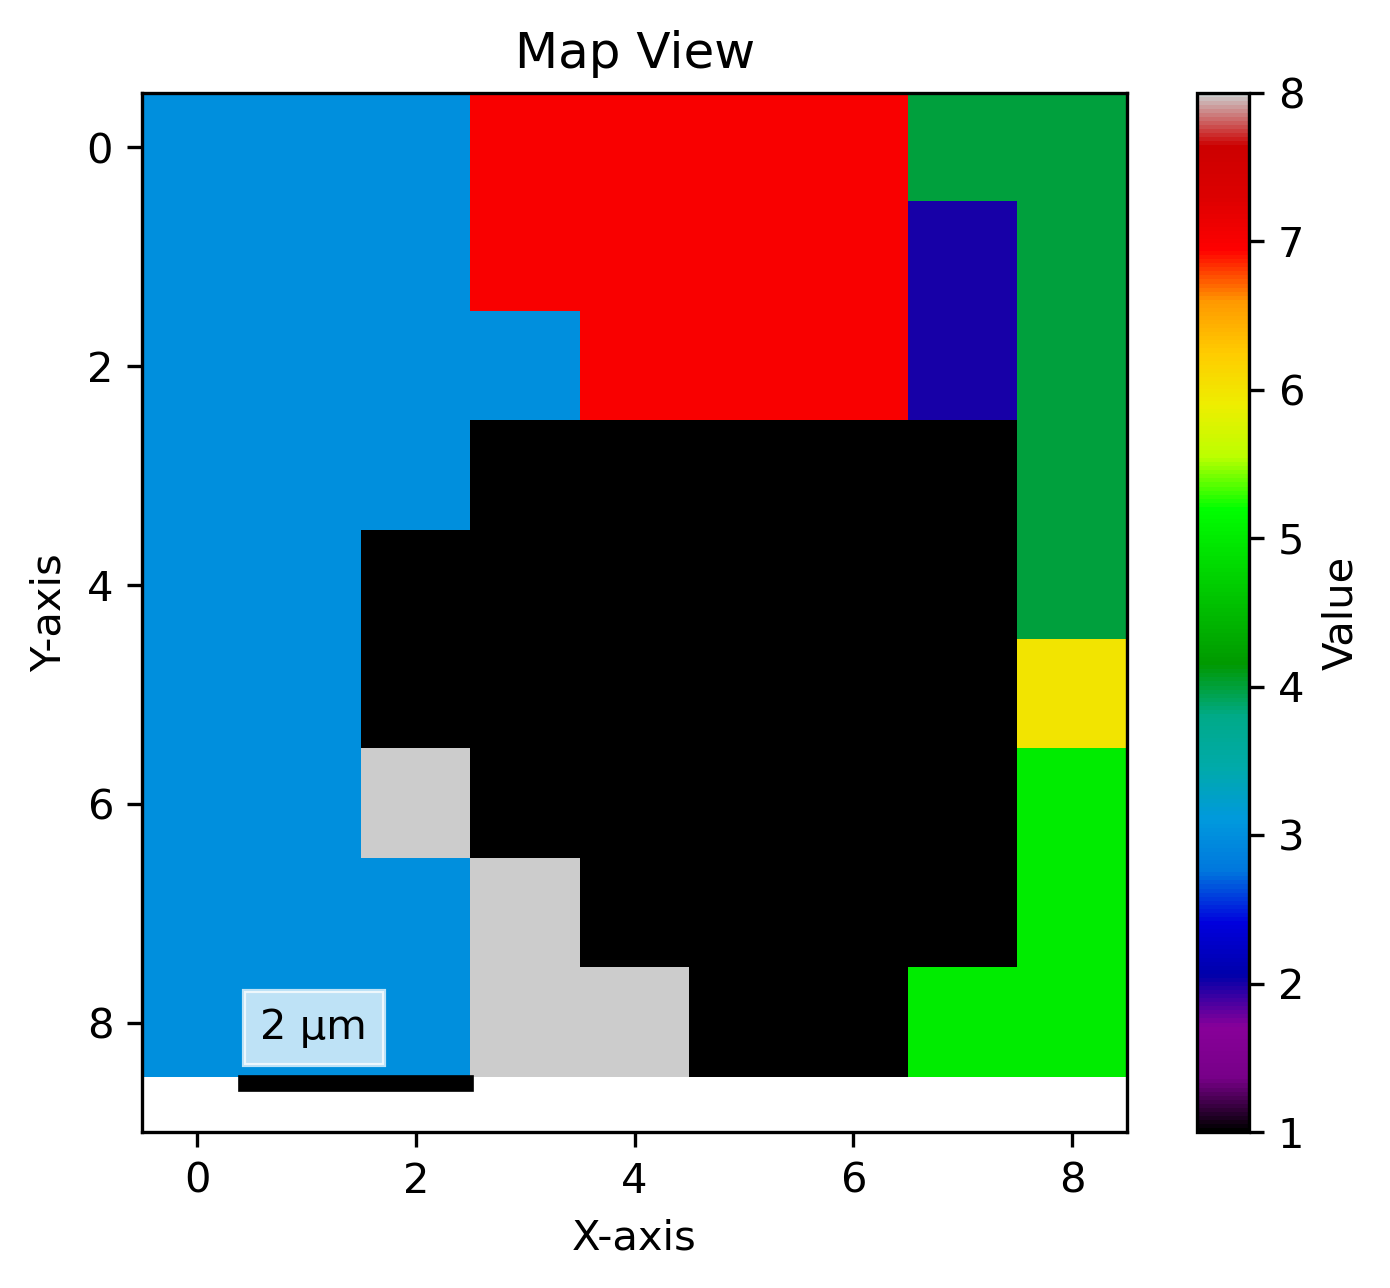

<Axes: title={'center': 'Map View'}, xlabel='X-axis', ylabel='Y-axis'>

In [ ]:
see_map(lfi, fids, cmap='nipy_spectral', preset='publication', 
        mbar=True, mbar_length=2)